In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import shap

# Load DataSet
df = pd.read_csv('/kaggle/input/datasets/furqan776/excel-sh/playstation_games_preprocessed.csv')

leak_cols = ['NA Sales', 'PAL Sales', 'Japan Sales', 'Other Sales', 'Total Shipped', 'Game', 'Name']
df_clean = df.drop(columns=leak_cols)

df_clean.head()

,Console,Publisher,Developer,Total Sales,Release Date,Last Update,rating,ratings_count,metacritic,genres,platforms,Year
0,PS4,Rockstar Games,Rockstar North,19390000.0,2014-11-18,2018-01-03,4.47,7225.0,92.0,Action,"PC, PlayStation 5, Xbox One, PlayStation 4, Xb...",2014
1,PS4,Rockstar Games,Rockstar Games,13940000.0,2018-10-26,2018-11-02,4.59,5357.0,96.0,Action,"PC, Xbox One, PlayStation 4",2018
2,PS4,Activision,Sledgehammer Games,13400000.0,2017-11-03,2017-12-31,3.54,1171.0,77.0,"Shooter, Action","PC, Xbox One, PlayStation 4",2017
3,PS4,EA Sports,EA Vancouver,11800000.0,2017-09-29,2018-04-02,3.36,700.0,79.0,Sports,"PC, Xbox One, PlayStation 4, Nintendo Switch, ...",2017
4,PS4,Electronic Arts,EA Canada,10940000.0,2016-09-27,2018-03-28,3.31,588.0,85.0,Sports,"PC, Xbox One, PlayStation 4, Xbox 360, PlaySta...",2016


In [2]:
# Feature Engineering
df_clean['Release Date'] = pd.to_datetime(df_clean['Release Date'], errors='coerce')
df_clean['Last Update'] = pd.to_datetime(df_clean['Last Update'], errors='coerce')

df_clean['Days_Since_Update'] = (df_clean['Last Update'] - df_clean['Release Date']).dt.days
df_clean['Days_Since_Update'].fillna(0, inplace=True)

df_clean['Release_Year'] = df_clean['Release Date'].dt.year
df_clean['Release_Month'] = df_clean['Release Date'].dt.month
df_clean.drop(columns=['Release Date', 'Last Update'], inplace=True)

df_clean['Num_Platforms'] = df_clean['platforms'].astype(str).apply(lambda x: len(x.split(',')))
df_clean['Num_Genres'] = df_clean['genres'].astype(str).apply(lambda x: len(x.split(',')))

publisher_mean = df_clean.groupby('Publisher')['Total Sales'].mean().to_dict()
df_clean['Publisher_Mean_Sales'] = df_clean['Publisher'].map(publisher_mean)

cat_cols = ['Console', 'Publisher', 'Developer', 'genres', 'platforms']
for c in cat_cols:
    le = LabelEncoder()
    df_clean[c] = le.fit_transform(df_clean[c].astype(str))

df_clean.fillna(0, inplace=True)

X = df_clean.drop(columns=['Total Sales'])
y = df_clean['Total Sales']

/tmp/ipykernel_17/2923080284.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Days_Since_Update'].fillna(0, inplace=True)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003457 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1228
[LightGBM] [Info] Number of data points in the train set: 677, number of used features: 15
[LightGBM] [Info] Start training from score 660103.397341
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

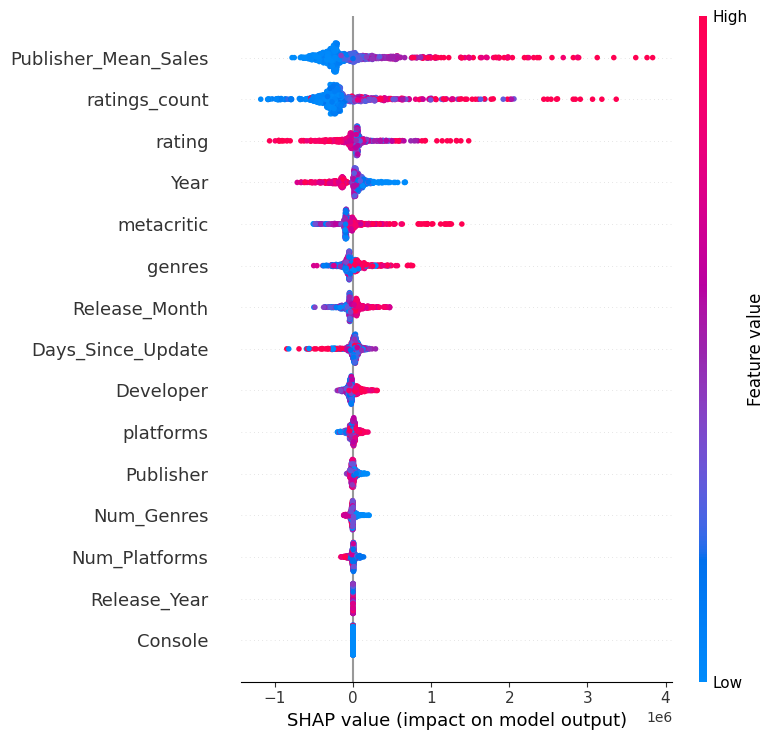

In [3]:
# Model Training 
lgb_model = lgb.LGBMRegressor(random_state=42)
lgb_model.fit(X, y)

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X)

print("Plotting SHAP Summary...")
shap.summary_plot(shap_values, X)

Four new features are added.

Days_Since_Update: This feature measures the lifespan of a game's active support by calculating the days between its initial release and its last recorded update.
Num_Platforms: Extracted from the platforms string, this represents the total number of hardware systems the game was released on.
Num_Genres: This counts how many genre tags are associated with a game.
Publisher_Mean_Sales: This is a target-encoded feature representing the average sales performance of the game's publisher.

A Feature Dropped is "Console"

Its because during the initial feature importance analysis using five different algorithms (Random Forest, GBM, etc.), the Console feature consistently ranked at the bottom with near-zero importance (approx. 0.007). Since the dataset is heavily dominated by the PS4, this feature provided almost no information gain. Removing it reduced the Root Mean Squared Error (RMSE)

In [4]:
# Standarization + K means 
X_dropped = X.drop(columns=['Console'])

scaler = StandardScaler()
num_cols = ['ratings_count', 'metacritic', 'Days_Since_Update', 'Num_Platforms', 'Num_Genres', 'Publisher_Mean_Sales', 'Year']
X_scaled = X_dropped.copy()
X_scaled[num_cols] = scaler.fit_transform(X_scaled[num_cols])

kmeans = KMeans(n_clusters=5, random_state=42)
X_scaled['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
final_model = lgb.LGBMRegressor(random_state=42)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Final LightGBM RMSE: {rmse:.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000147 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1047
[LightGBM] [Info] Number of data points in the train set: 541, number of used features: 15
[LightGBM] [Info] Start training from score 637356.746765
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

K-Means clustering (k=5) was applied to the standardized numerical features. This created a new feature called KMeans_Cluster. This feature groups "similar" games together based on their statistical profiles (e.g., high-rated/low-sales vs. low-rated/high-sales). Adding these cluster labels provides the LightGBM model with a high-level categorical "profile" of each game.

In [5]:
final_df = X_scaled.copy()
final_df['Total_Sales'] = y
final_df.to_csv('ML_Project_Phase_3_Final.csv', index=False)